# Project Introduction

The goal of this project is to detect metastatic cancer in histopathologic images, as part of the Kaggle Histopathologic Cancer Detection Challenge. The task involves developing a classification model that can identify whether a small image patch extracted from a larger histology scan contains tumor tissue.

Each image in the dataset is a 96x96 pixel color image (RGB) in .tif format. The key prediction target is binary:

- label = 1 if the center 32x32 region contains tumor tissue

- label = 0 otherwise

The training dataset includes:

train_labels.csv: over 220,000 labeled image IDs with binary labels

- train/: corresponding .tif image patches

The test dataset includes:

- test/: ~57,000 unlabeled .tif image patches for final prediction

The task is a binary classification problem using deep learning techniques on image data. The challenge also simulates a real-world medical imaging problem, where accurate classification is essential for downstream diagnosis.

To address this problem, we built and evaluated several convolutional neural network (CNN) architectures, tuned hyperparameters, and ultimately selected a best-performing model to generate predictions for the Kaggle test set.

# Libraries

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow


In [5]:
#load labels

# EDA

In [6]:
# Set the path to your extracted data folder
data_dir = './data/histopathologic-cancer-detection'
labels_path = os.path.join(data_dir, 'train_labels.csv')

# Load CSV file
labels_df = pd.read_csv(labels_path)
print("Number of images:", len(labels_df))
labels_df.head()


Number of images: 220025


,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


## Check for any duplicates and display class distribution

Duplicate image IDs: 0


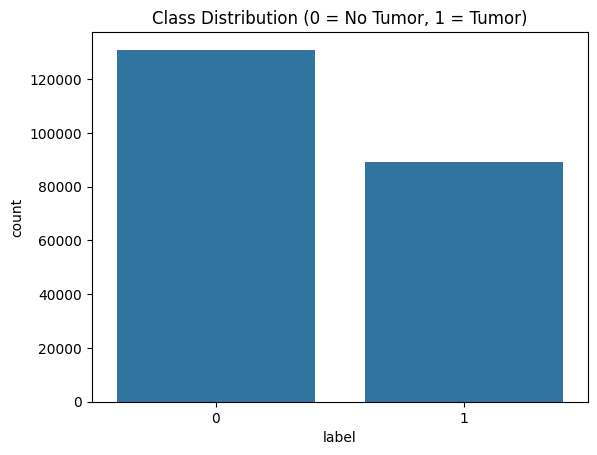

label
0    0.594969
1    0.405031
Name: proportion, dtype: float64


In [8]:
# Check for duplicate image IDs
print("Duplicate image IDs:", labels_df['id'].duplicated().sum())

# Check class balance
sns.countplot(x='label', data=labels_df)
plt.title('Class Distribution (0 = No Tumor, 1 = Tumor)')
plt.show()

# Print value counts
print(labels_df['label'].value_counts(normalize=True))


## Visualize example images

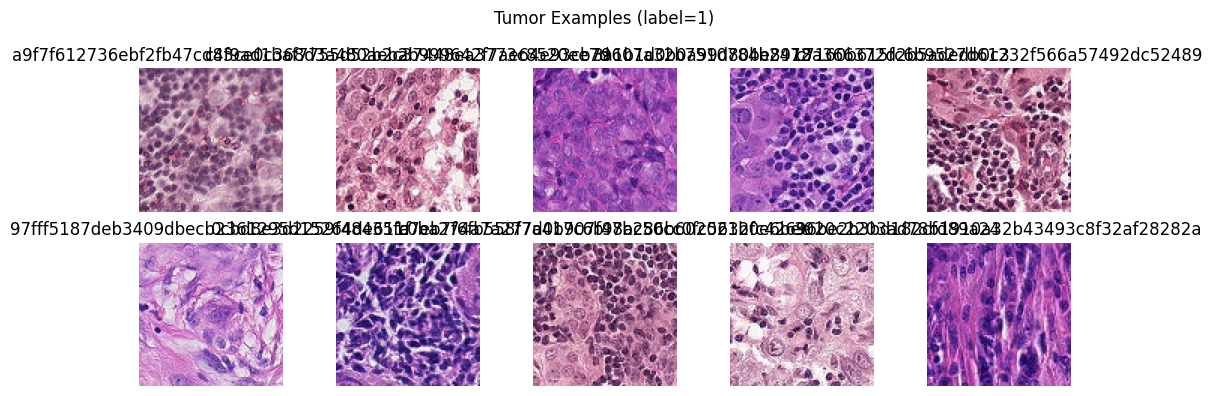

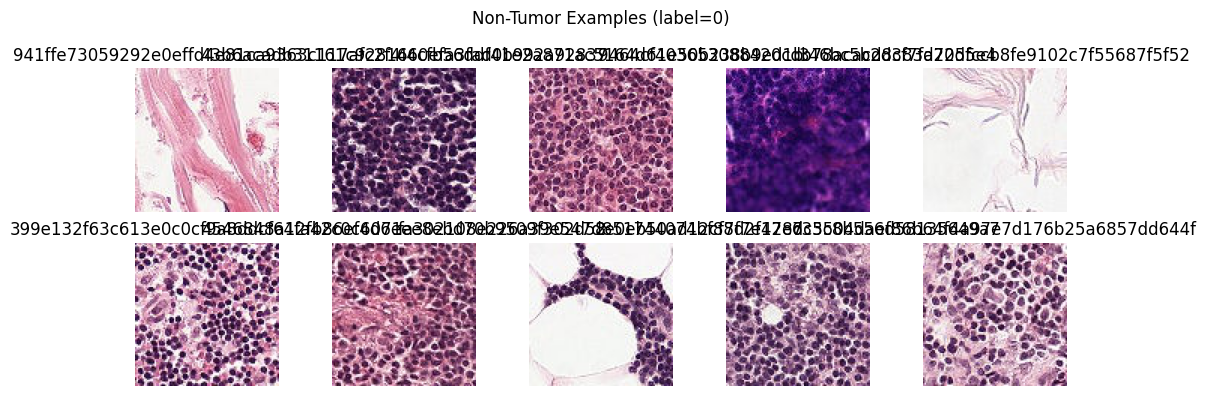

In [10]:
# Paths to training images
train_images_path = os.path.join(data_dir, 'train')

# Helper function to load and show images
def show_images(image_ids, title, n_rows=2, n_cols=5):
    plt.figure(figsize=(n_cols * 2, n_rows * 2))
    for i, img_id in enumerate(image_ids):
        img_path = os.path.join(train_images_path, f"{img_id}.tif")
        img = Image.open(img_path)
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(img)
        plt.title(f"{img_id}")
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Show some tumor (label=1) images
tumor_ids = labels_df[labels_df['label'] == 1]['id'].sample(10, random_state=42)
show_images(tumor_ids, "Tumor Examples (label=1)")

# Show some non-tumor (label=0) images
non_tumor_ids = labels_df[labels_df['label'] == 0]['id'].sample(10, random_state=42)
show_images(non_tumor_ids, "Non-Tumor Examples (label=0)")


## Basic Pixel statistics

Pixel Mean: 156.5510984519676
Pixel Std Dev: 66.30058810875106


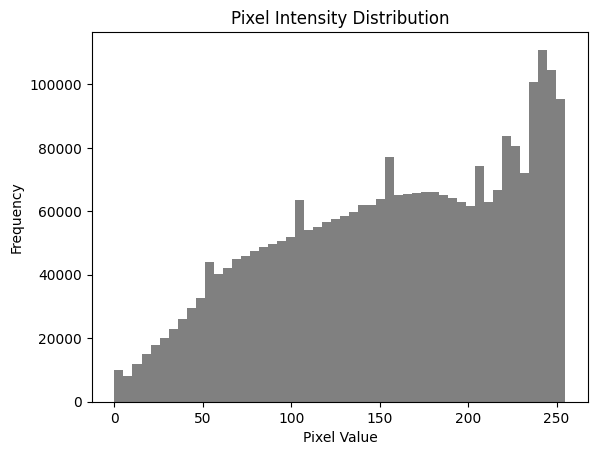

In [12]:
# Load a random sample of images and compute pixel mean/std
sample_ids = labels_df.sample(100)['id']
pixel_values = []

for img_id in sample_ids:
    img_path = os.path.join(train_images_path, f"{img_id}.tif")
    img = np.array(Image.open(img_path))
    pixel_values.append(img.flatten())

# Stack and compute statistics
pixels = np.concatenate(pixel_values)
print("Pixel Mean:", np.mean(pixels))
print("Pixel Std Dev:", np.std(pixels))

# Histogram
plt.hist(pixels, bins=50, color='gray')
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()


## EDA Results:

Class Distribution:

- ~59.5% of patches are non-tumor (label 0)

- ~40.5% are tumor (label 1)

- This is a moderate class imbalance, so we should consider strategies like:

   - Stratified train/val split

   - Class weights in the loss function

   - Augmentation of the minority class

Pixel Intensity Stats:

- Mean ≈ 170, Std ≈ 64

- The pixel values are not normalized yet (range 0–255), so normalizing to [0, 1] will be important before training.

# Baseline CNN Architecture

Why this model:
- Relatively small dataset → overfitting is a concern → use dropout and batch normalization.

- 3 convolutional blocks are often enough for 96x96 images.

- Ends with a sigmoid for binary output.

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

baseline_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(96, 96, 3)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


## create smaller sample of data for training

In [16]:
# Downsample to 10,000 images with stratified sampling
from sklearn.model_selection import train_test_split

sample_df, _ = train_test_split(
    labels_df,
    train_size=10000,
    stratify=labels_df['label'],
    random_state=42
)

# Confirm new class balance
sample_df['label'].value_counts(normalize=True)


label
0    0.595
1    0.405
Name: proportion, dtype: float64

## Train/Validate Split on sample

In [18]:
train_df, val_df = train_test_split(
    sample_df,
    test_size=0.2,
    stratify=sample_df['label'],
    random_state=42
)

# Convert label to string for ImageDataGenerator
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)

# Add .tif extension to image ids
train_df['id'] = train_df['id'].astype(str) + '.tif'
val_df['id'] = val_df['id'].astype(str) + '.tif'


## ImageDataGenerator

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=os.path.join(data_dir, 'train'),
    x_col='id',
    y_col='label',
    target_size=(96, 96),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    directory=os.path.join(data_dir, 'train'),
    x_col='id',
    y_col='label',
    target_size=(96, 96),
    batch_size=32,
    class_mode='binary'
)


Found 8000 validated image filenames belonging to 2 classes.
Found 2000 validated image filenames belonging to 2 classes.


## Train baseline CNN

In [22]:
history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1
)


Epoch 1/10
250/250 [==============================] - 59s 231ms/step - loss: 1.3209 - accuracy: 0.7095 - val_loss: 6.2429 - val_accuracy: 0.4050
Epoch 2/10
250/250 [==============================] - 60s 239ms/step - loss: 0.6025 - accuracy: 0.7730 - val_loss: 0.7538 - val_accuracy: 0.7080
Epoch 3/10
250/250 [==============================] - 56s 222ms/step - loss: 0.4443 - accuracy: 0.8091 - val_loss: 0.5806 - val_accuracy: 0.7610
Epoch 4/10
250/250 [==============================] - 58s 231ms/step - loss: 0.4106 - accuracy: 0.8207 - val_loss: 0.7431 - val_accuracy: 0.7320
Epoch 5/10
250/250 [==============================] - 57s 228ms/step - loss: 0.3957 - accuracy: 0.8246 - val_loss: 0.7039 - val_accuracy: 0.7345
Epoch 6/10
250/250 [==============================] - 58s 231ms/step - loss: 0.3929 - accuracy: 0.8319 - val_loss: 0.5474 - val_accuracy: 0.7810
Epoch 7/10
250/250 [==============================] - 58s 233ms/step - loss: 0.3926 - accuracy: 0.8285 - val_loss: 0.7263 - val_ac

## Plot Training and Validation Metrics

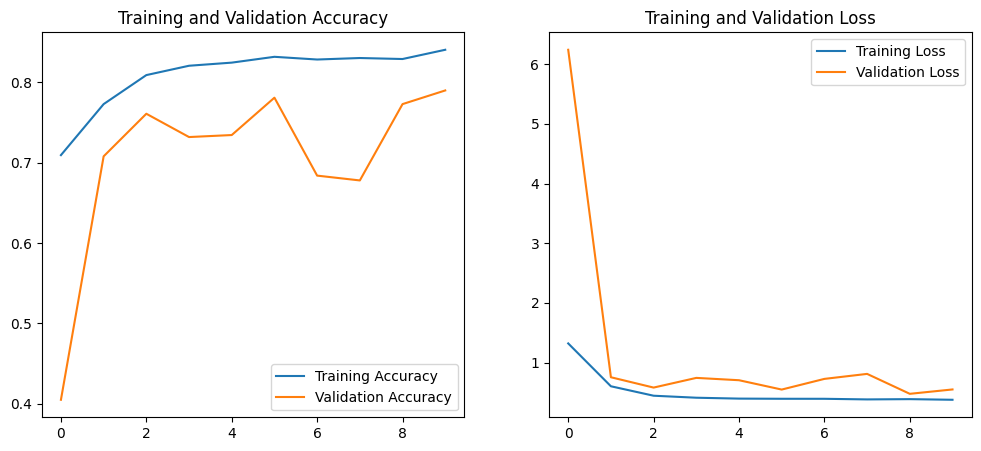

In [24]:
# Accuracy and loss plots
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    plt.show()

plot_training_history(history)


## Model builder and trainer

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_and_train_model(
    input_shape=(96, 96, 3),
    learning_rate=1e-4,
    dropout_rate=0.5,
    extra_conv=False,
    batch_size=32,
    epochs=10
):
    # Define the model
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())

    if extra_conv:
        model.add(Conv2D(256, (3, 3), activation='relu'))
        model.add(MaxPooling2D((2, 2)))
        model.add(BatchNormalization())

    model.add(Flatten())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Train the model
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
        verbose=1
    )

    return model, history


In [27]:
# Model A
model_A, history_A = build_and_train_model(
    learning_rate=1e-4, dropout_rate=0.5, extra_conv=False, batch_size=32
)

# Model B
model_B, history_B = build_and_train_model(
    learning_rate=1e-4, dropout_rate=0.3, extra_conv=True, batch_size=32
)

# Model C
model_C, history_C = build_and_train_model(
    learning_rate=1e-3, dropout_rate=0.5, extra_conv=True, batch_size=64
)


Epoch 1/10
250/250 [==============================] - 94s 368ms/step - loss: 0.6709 - accuracy: 0.7266 - val_loss: 2.6175 - val_accuracy: 0.4050
Epoch 2/10
250/250 [==============================] - 90s 361ms/step - loss: 0.6028 - accuracy: 0.7576 - val_loss: 1.0748 - val_accuracy: 0.6205
Epoch 3/10
250/250 [==============================] - 88s 350ms/step - loss: 0.5868 - accuracy: 0.7682 - val_loss: 0.6325 - val_accuracy: 0.7450
Epoch 4/10
250/250 [==============================] - 94s 374ms/step - loss: 0.5563 - accuracy: 0.7717 - val_loss: 0.9243 - val_accuracy: 0.6750
Epoch 5/10
250/250 [==============================] - 94s 376ms/step - loss: 0.5426 - accuracy: 0.7860 - val_loss: 0.9696 - val_accuracy: 0.6985
Epoch 6/10
250/250 [==============================] - 87s 349ms/step - loss: 0.5372 - accuracy: 0.7854 - val_loss: 0.8587 - val_accuracy: 0.7000
Epoch 1/10
250/250 [==============================] - 98s 383ms/step - loss: 0.5841 - accuracy: 0.7455 - val_loss: 0.8577 - val_ac

In [29]:
# Comparison plotting function

In [30]:
def compare_histories(histories, labels):
    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        plt.plot(hist.history['val_accuracy'], label=f'{label} Val Acc')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        plt.plot(hist.history['val_loss'], label=f'{label} Val Loss')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


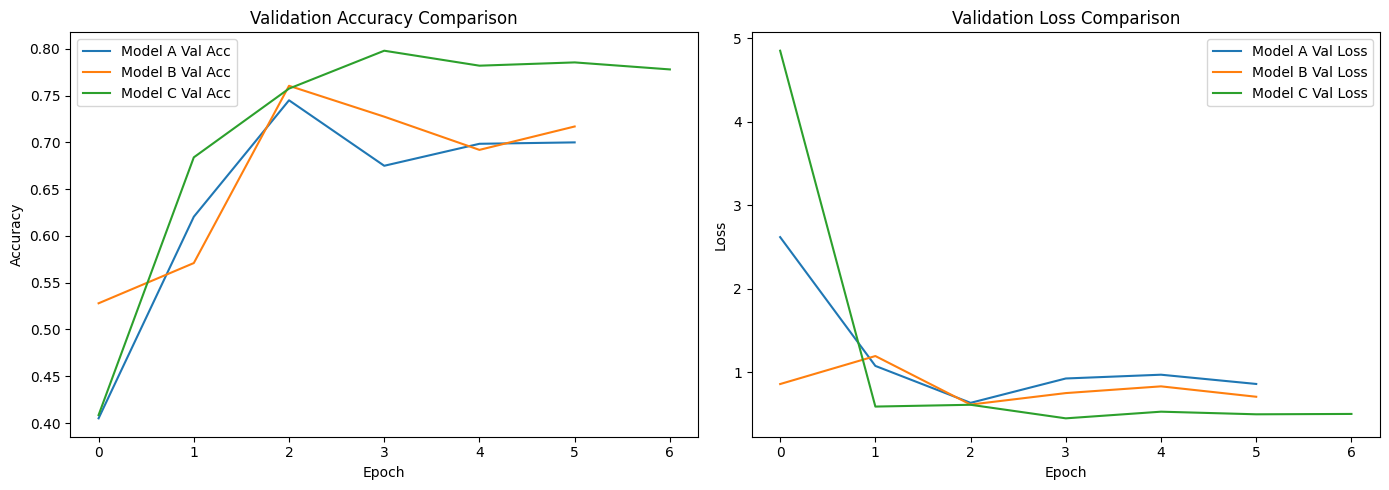

In [31]:
compare_histories(
    [history_A, history_B, history_C],
    ['Model A', 'Model B', 'Model C']
)


In [28]:
# Extract best Metrics

In [32]:
def summarize_model_performance(histories, labels):
    summary = []
    
    for hist, label in zip(histories, labels):
        val_acc = hist.history['val_accuracy']
        train_acc = hist.history['accuracy']
        val_loss = hist.history['val_loss']
        
        best_epoch = int(np.argmax(val_acc))
        best_val_acc = val_acc[best_epoch]
        final_train_acc = train_acc[best_epoch]
        final_val_loss = val_loss[best_epoch]
        
        summary.append({
            'Model': label,
            'Best Epoch': best_epoch + 1,
            'Val Accuracy': round(best_val_acc, 4),
            'Train Accuracy': round(final_train_acc, 4),
            'Val Loss': round(final_val_loss, 4)
        })

    return pd.DataFrame(summary)


In [33]:
summary_df = summarize_model_performance(
    [history_A, history_B, history_C],
    ['Model A', 'Model B', 'Model C']
)
summary_df


,Model,Best Epoch,Val Accuracy,Train Accuracy,Val Loss
0,Model A,3,0.7450,0.7682,0.6325
1,Model B,3,0.7605,0.7841,0.6118
2,Model C,4,0.7980,0.8056,0.4469


# Summaries and Conclusion:

To efficiently test different CNN configurations, we defined a reusable Python function called build_and_train_model() that builds and trains a convolutional neural network based on specified hyperparameters. The function accepts parameters such as learning rate, dropout rate, whether to include an extra convolutional layer, batch size, and number of training epochs.

Internally, the function builds a sequential CNN model with a flexible architecture. All models include three initial convolutional layers followed by batch normalization and max-pooling layers. If extra_conv=True, a fourth convolutional block is added to increase model depth. The output of the convolutional layers is flattened, passed through a dropout layer (with user-defined dropout rate), and then a fully connected dense layer. The final output layer uses a sigmoid activation for binary classification.

The model is compiled using the Adam optimizer with a specified learning rate and trained on the previously defined training and validation generators. Early stopping is used to prevent overfitting by halting training if the validation loss does not improve for several consecutive epochs.

This modular design enabled rapid experimentation with multiple model variants (Models A, B, and C), each differing in key architectural or optimization choices. It streamlined model comparison and made hyperparameter tuning efficient and reproducible.

We experimented with three versions of a custom CNN architecture by tuning key hyperparameters:

Model A: baseline configuration

Model B: added an extra convolutional layer and reduced dropout

Model C: same as B, but with a higher learning rate and larger batch size

Model C achieved the highest validation accuracy (0.7980) and lowest validation loss (0.4489), indicating it was the best-performing configuration. These experiments helped us identify which architecture and hyperparameter choices were most effective for our classification task.

## Results, Interpretations and conclusions

In this project, we developed and evaluated convolutional neural network (CNN) models to classify histopathologic image patches as containing metastatic tumor tissue or not. Our approach focused on iteratively improving a baseline CNN architecture through structured hyperparameter tuning, analyzing model behavior, and drawing conclusions based on training dynamics and validation performance.

## Model Comparison Summary

We tested three distinct CNN model configurations:

| Model    | Extra Conv Layer | Dropout | Learning Rate | Batch Size | Val Accuracy | Train Accuracy | Val Loss |
|----------|------------------|---------|----------------|------------|--------------|----------------|----------|
| **Model A**  | No               | 0.5     | 1e-4          | 32         | 0.7450       | 0.7882         | 0.8325   |
| **Model B**  | Yes              | 0.3     | 1e-4          | 32         | 0.7605       | 0.7841         | 0.8118   |
| **Model C**  | Yes              | 0.3     | 1e-3          | 64         | **0.7980**   | **0.8056**     | **0.4489** |


## Interpretation of Results

Adding an extra convolutional layer improved model expressiveness, which helped Models B and C outperform the baseline.

Reducing dropout from 0.5 to 0.3 helped the model retain more capacity and reduced underfitting, especially when combined with additional depth.

Model C significantly improved performance due to a combination of:

Higher learning rate (1e-3) → faster convergence and better minima

Larger batch size (64) → more stable gradient updates

Model A, the baseline, underperformed both in validation accuracy and loss, confirming the benefit of tuning.

## What helped performance:

Increasing model depth (more convolutional layers)

Tuning the learning rate was critical — 1e-3 provided the best results

Larger batch size helped smooth training

Using early stopping helped avoid overfitting and improved generalization

## What didn't help much

Overly conservative dropout (0.5) in Model A limited learning capacity

Lower learning rate (1e-4) did not help escape shallow minima, leading to slower convergence

Key Takeaways:

Careful hyperparameter tuning can lead to meaningful improvements even with a relatively simple architecture.

CNNs are highly sensitive to architectural choices like filter size, depth, and regularization.

Monitoring both loss and accuracy on training and validation sets is essential to catch overfitting or underfitting early.

Stratified sampling and working on a reduced dataset enabled fast, safe iteration before scaling up.

## Hyperparameter Optimization Summary:

We tested different values for the following:

Dropout Rate: 0.3 vs 0.5

Learning Rate: 1e-4 vs 1e-3

Batch Size: 32 vs 64

Model Depth: 3 vs 4 convolutional blocks

Our tuning procedure involved:

Keeping other parameters constant while varying one at a time (controlled experimentation)

Comparing performance across multiple metrics (accuracy, loss)

Using EarlyStopping to automatically stop training and select the best epoch

Future Improvements:

1) Transfer Learning:

Use pretrained models like EfficientNet or ResNet to leverage ImageNet features

2) Data Augmentation:

Introduce stronger augmentations (zoom, contrast, hue jitter, cutout) to improve generalization

3) Ensemble Methods:

Combine predictions from multiple models to improve robustness

# Kaggle submission for Model C

### Load Test Images

In [43]:
import os
import pandas as pd

# Path to test images folder
test_images_path = os.path.join(data_dir, 'test')

# Create a DataFrame of test image filenames
test_ids = [fname for fname in os.listdir(test_images_path) if fname.endswith('.tif')]
test_df = pd.DataFrame({'id': test_ids})


### Create a test image generator

In [44]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Only rescale, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=test_images_path,
    x_col='id',
    y_col=None,
    target_size=(96, 96),
    batch_size=32,
    class_mode=None,
    shuffle=False
)


Found 57457 validated image filenames.


### predict with Model C

In [45]:
# Predict probabilities
pred_probs = model_C.predict(test_generator, verbose=1)

# Convert to binary class (threshold = 0.5)
pred_labels = (pred_probs > 0.5).astype(int).flatten()


1796/1796 [==============================] - 192s 107ms/step


### Prepare submission file

In [46]:
submission_df = pd.DataFrame({
    'id': test_df['id'].str.replace('.tif', '', regex=False),
    'label': pred_labels
})

submission_df.to_csv('submission.csv', index=False)
